# EXAMEN ABRIL 2026 PABLO CORBALÁN DE CONCEPCIÓN 

### 2º DTIE MATEMÁTICAS Y FÍSICA CURSO 2025-2026

#### Resolución del ejercicio (C)

Se resuelve numéricamente el ejercicio planteado en el apartado (B). Para ello consideraremos una partición discreta del intervalo de tiempo $\left[t_0, t_f\right]$ como se explicita a continuación:

$$t := \{t_0 \leq t_1 \leq \cdots \leq t_N \leq t_N+1 = t_f\}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Estableciendo las siguientes condiciones iniciales: 

In [65]:
m=0.04     # kg
kx=4*pow(10, -4)    # Constante elástica en la componente x en  N / m
ky=1*pow(10, -4)    # Constante elástica en la componente y en N / m
x0=0.2     # m
y0=0       # m
vx0=0      # m/s
vy0=-0.015 # m / s

t0=0       
tf=300
N=100000

# Escribo el delta de t en función de la N
delta=(tf-t0)/(N)

In [66]:
# Creo los arrays de datos para para calcular numéricamente x, y, vx, vy
t=np.linspace(t0,tf,N+1)
x=np.zeros(N+1)
y=np.zeros(N+1)
vx=np.zeros(N+1)
vy=np.zeros(N+1)

In [67]:
x[0]=x0
y[0]=y0
vx[0]=vx0
vy[0]=vy0

In [68]:
for i in range (0, N):
    # Implementación del algoritmo de Euler modificado 
    vx[i+1]=vx[i]-(kx/m)*x[i]*delta
    vy[i+1]=vy[i]-(ky/m)*y[i]*delta
    x[i+1]=x[i]+vx[i+1]*delta
    y[i+1]=y[i]+vy[i+1]*delta

### Resolución del ejercicio (D)

Representamos gráficamente la trayectoria de la partícula en el plano XY. Para ello utilizamos la libreria MatplotLib.

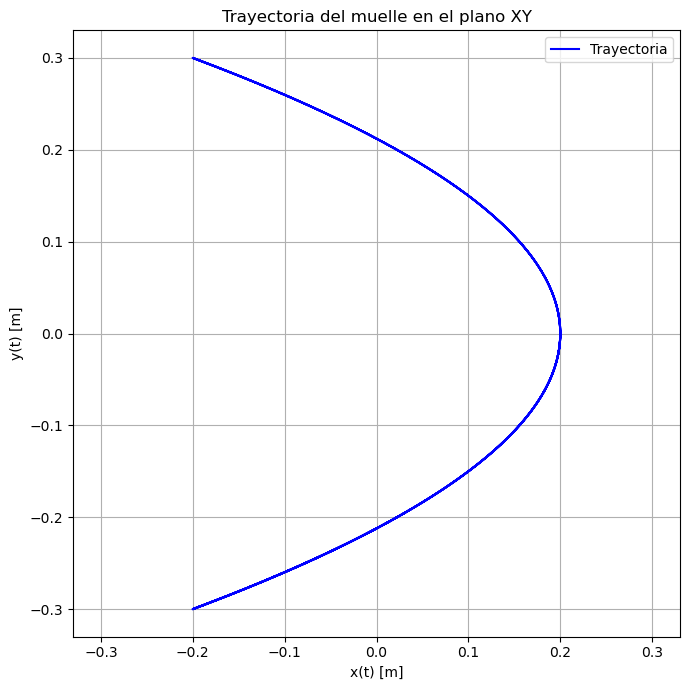

In [69]:
plt.figure(figsize=(7,7))
plt.plot(x,y,label='Trayectoria',color='BLUE')
plt.title("Trayectoria del muelle en el plano XY")
plt.xlabel("x(t) [m]")
plt.ylabel("y(t) [m]")
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.legend()
plt.show()

### Resolución del ejercicio (E)

Comencemos estudiando las posiciones individuales de las componentes $x(t)$ e $y(t)$ frente al tiempo:

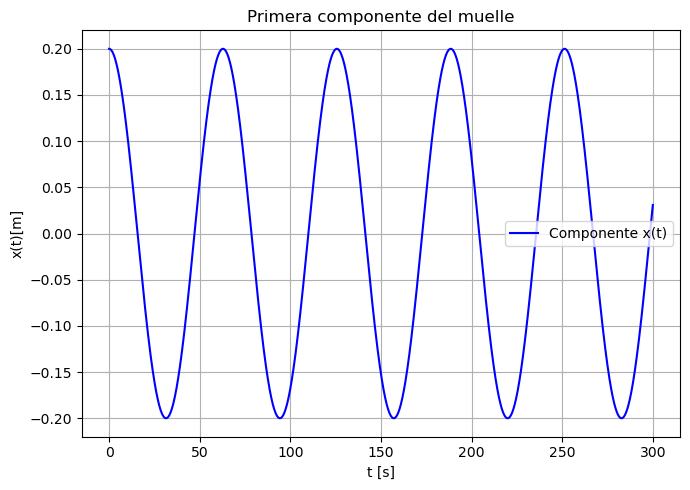

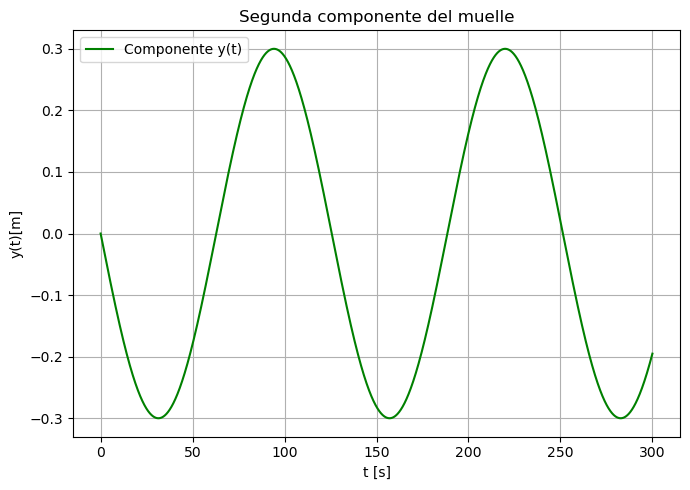

In [84]:
plt.figure(figsize=(7,5))
plt.plot(t,x,label='Componente x(t)',color='BLUE')
plt.title("Primera componente del muelle")
plt.xlabel("t [s]")
plt.ylabel("x(t)[m]")
plt.grid(True)
plt.tight_layout()
plt.legend()

plt.figure(figsize=(7,5))
plt.plot(t,y,label='Componente y(t)',color='GREEN')
plt.title("Segunda componente del muelle")
plt.xlabel("t [s]")
plt.ylabel("y(t)[m]")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

Donde se aprecia claramente la naturaleza oscilatoria en ambas componentes: describiendo un movimiento armónico simple.

Para entender mejor el funcionamiento de el muelle sometido a esta fuerza, podemos estudiar la norma del vector posición de una partícula sometida a la acción de esta fuerza:

$$r(t) = \sqrt{x(t)^2 + y(t)^2}$$

Lo que nos permite apreciar perfectamente el carácter oscilatorio del movimiento:

In [75]:
distancia = np.zeros(N+1)
for i in range (0,N+1):
    distancia[i]=np.sqrt(x[i]**2+y[i]**2)

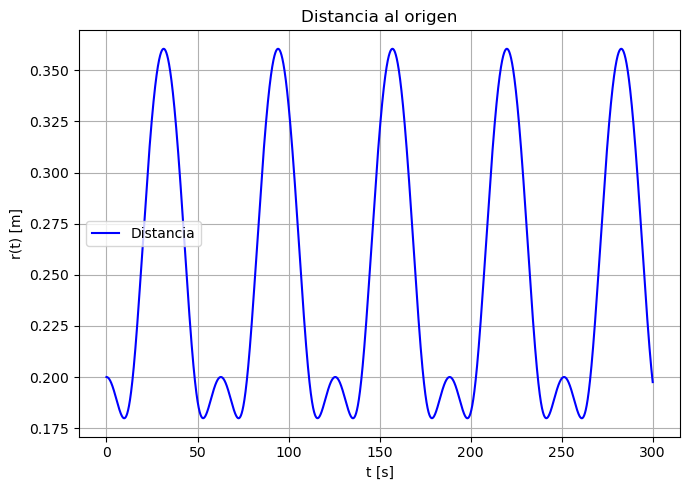

In [76]:
plt.figure(figsize=(7,5))
plt.plot(t,distancia,label='Distancia',color='BLUE')
plt.title("Distancia al origen")
plt.xlabel("t [s]")
plt.ylabel("r(t) [m]")
plt.grid(True)
plt.tight_layout();plt.legend();plt.show()

Además, por tratarse de un movimiento oscilatorio podemos calcular computacionalmente el periodo. Para ello trabajaremos con una tolerancia en cada componente $\epsilon_x, \epsilon_y$ y nos preguntaremos cuando la respectiva componente de la velocidad cae dentro del intervalo de confianza de la susodicha tolerancia. 

In [88]:
epsilonx=0.00001
epsilony=0.00001
# Descartamos los primeros puntos
for i in range (50,N+1): 
    if abs(x[i]-x[0])<epsilonx :
        Tx=t[i]
        break
print (f"Periodo x = {Tx:.3f} seg")

for i in range (50,N+1): 
    if abs(y[i]-y[0])<epsilony :
        # Es más fácil preguntarse cuando la y (que parte del origen) ha completado una oscilación. 
        # Esto nos permite estudiar el semiperiodo en el eje y
        semiTy=t[i]  
        break
print (f"Periodo y = {2*semiTy:.3f} seg")

Periodo x = 62.733 seg
Periodo y = 125.664 seg


Como el periodo en la componente y es aproximadamente dos veces el periodo en la componente x, ambas coincidirán cada periodo completo:

$$T \approx 125.664 s$$

Que cuadra con las gráficas de $x(t)$ frente a $t$ y de $y(t)$ frente a t

Además, podemos efectuar el estudio energético del muelle para así comprobar el Principio de Conservaciónd de la Energía Mecánica: una forma de verificar que nuestra implementación computacional es correcta. 

La energía cinética de un muelle se define como:

$$K(t) = \frac{1}{2} \cdot m \cdot v(t)$$

Donde $v(t)$ es la magnitud celeridad o módulo de la velocidad, en nuestro caso particular:

$$v(t) = \sqrt{v_x(t)^2 + v_y(t)^2}$$

La energía potencial de este muelle en dos dimensiones será:

$$F(t) = -\frac{dU}{dt}(t) \implies U(t) = \frac{1}{2} \cdot \left(k_x \cdot x(t)^2 + k_y \cdot y(t) ^2\right)$$

Nos preguntamos si la energía mecánica es constante, es decir:

$$E(t) = K(t) + U(t) = E_0$$

In [47]:
K=np.zeros(N+1)
U=np.zeros(N+1)
E=np.zeros(N+1)

for i in range (0,N+1):
    K[i]=(1/2)*m*(vx[i]**2+vy[i]**2)
    U[i]=(1/2)*(kx*x[i]**2+ky*y[i]**2)
    E[i]=K[i]+U[i]

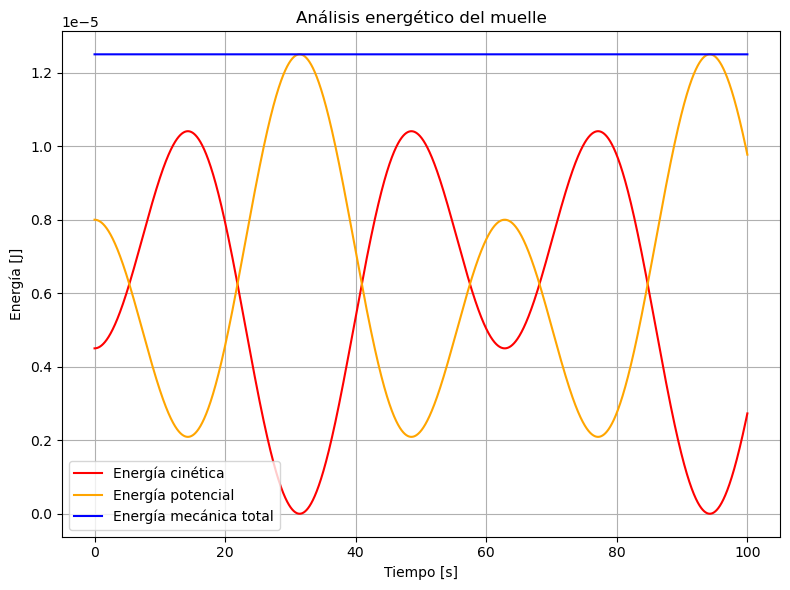

In [48]:
plt.figure(figsize=(8,6))
plt.plot(t,K,label='Energía cinética ',color='RED')
plt.plot(t,U,label='Energía potencial ',color='ORANGE')
plt.plot(t,E,label='Energía mecánica total',color='BLUE')
plt.title("Análisis energético del muelle")
plt.xlabel("Tiempo [s]")
plt.ylabel("Energía [J]")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

Efectivamente la energía mecánica total se conserva.

### Resolución del ejercicio (f)

Procedemos de forma similar al cálculo del periodo, comencemos por representar las componentes de la velocidad

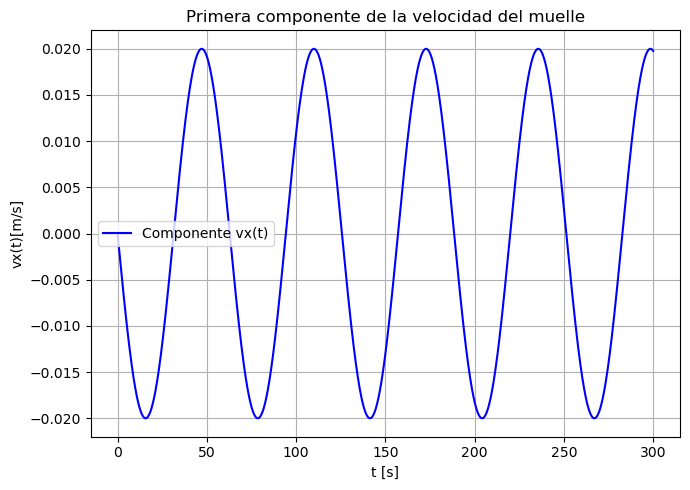

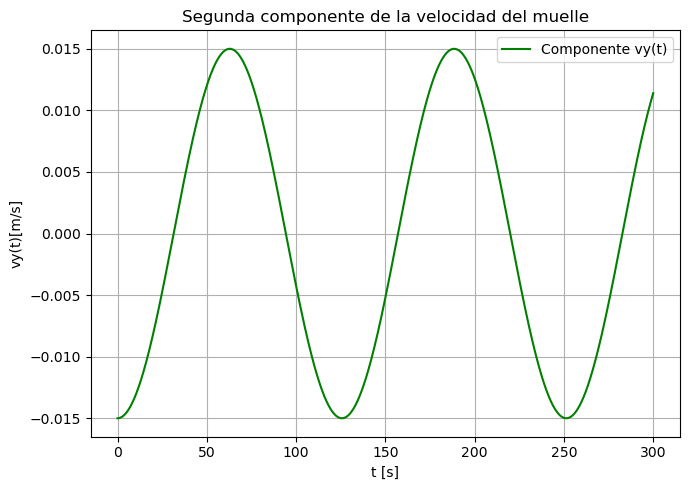

In [90]:
plt.figure(figsize=(7,5))
plt.plot(t,vx,label='Componente vx(t)',color='BLUE')
plt.title("Primera componente de la velocidad del muelle")
plt.xlabel("t [s]")
plt.ylabel("vx(t)[m/s]")
plt.grid(True)
plt.tight_layout()
plt.legend()

plt.figure(figsize=(7,5))
plt.plot(t,vy,label='Componente vy(t)',color='GREEN')
plt.title("Segunda componente de la velocidad del muelle")
plt.xlabel("t [s]")
plt.ylabel("vy(t)[m/s]")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

Para calcular el instante en el que la velocidad de la partícula es cero, vamos a utilizar la magnitud celeridad o módulo del vector velocidad, definida previamente como

$$v(t) := \sqrt{v_x(t)^2 + v_y(t)^2}$$

Que se corresponde con la norma euclídea en $\mathbb{R}^2$. Utilizando la primera propiedad de la norma:

$$||v|| \geq 0 \text{ y } ||v|| = 0 \iff v = 0$$

Concluimos que es suficiente estudiar cuando la velocidad (en módulo) se anula para determinar un punto de tiempo en el que la velocidad sea nula.

In [53]:
celeridad = np.zeros(N+1)
for i in range (N+1):
    celeridad[i]=np.sqrt(vx[i]**2+vy[i]**2)

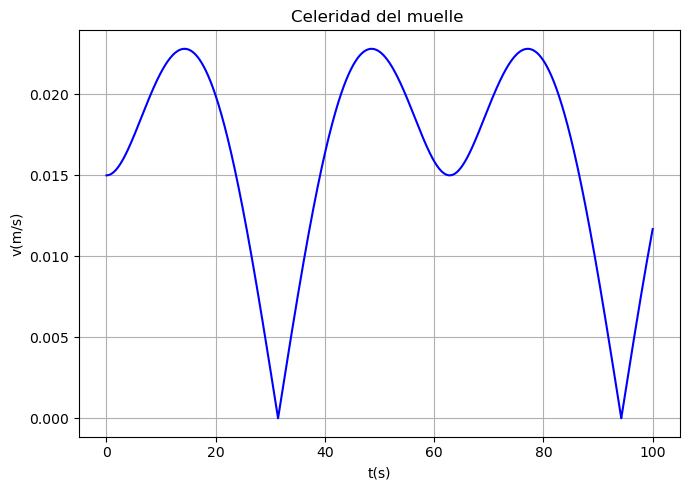

In [54]:
plt.figure(figsize=(7,5))
plt.plot(t,celeridad,color='BLUE')
plt.title("Celeridad del muelle ")
plt.xlabel("t(s)")
plt.ylabel("v(m/s)")
plt.grid(True)
plt.tight_layout();
plt.show()

En la gráfica vemos claramente que hay un punto en el que la celeridad es cero (y por tanto la velocidad será nula en el susodicho punto). Para determinar qué punto es vamos a proceder de la misma forma que con el periodo, estableciendo una tolerancia $\epsilon_v$ y preguntándonos cuando la celeridad cae en el intervalo de confianza $$\left[-\epsilon_v, \epsilon_v\right]$$


In [59]:
epsilonv=0.0001
for i in range (15,N+1): 
    if abs(celeridad[i])<epsilonv:
        tiempo_celeridad_nula=t[i]
        posicion_celeridad_nula=i
        break
print (f"Tiempo de velocidad nula = {tiempo_celeridad_nula:.3f} seg")
print(f"Velocidad en el tiempo de velocidad nula = {celeridad[posicion_celeridad_nula]:.3f}")

Tiempo de velocidad nula = 31.370 seg
Velocidad en el tiempo de velocidad nula = 0.000


Que coincide con lo representado en las anteriores gráficas.